

<h2>AMAÇ</h2>

<p style="text-indent: 40px; text-align: justify;">
Bu çalışmada, şarapların fizikokimyasal özellikleri kullanılarak kalite tahmini yapılmış ve aynı zamanda bir şarabı “iyi” yapan fizikokimyasal özellikler incelenmiştir. Bu kapsamda, farklı makine öğrenmesi modelleri kurularak şarap kalitesinin tahmin edilebilirliği değerlendirilmiş; elde edilen modeller aracılığıyla değişkenlerin kalite üzerindeki göreli etkileri analiz edilmiştir. Model performans metrikleri, hem tahmin başarısını değerlendirmek hem de elde edilen bulguların güvenilirliğini desteklemek amacıyla kullanılmıştır.
</p>


In [2]:
import pandas as pd
import numpy as np;

In [3]:
data = pd.read_csv("winequality-red.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
data.shape

(1599, 12)

<p style="color: green; text-align: justify;">
Veri seti 1599 gözlem ve 12 değişkenden oluşmaktadır. Fizikokimyasal özellikleri temsil eden 11 değişken sayısal yapıdadır. Hedef değişken olan quality sütunu tamsayı tipinde ve sıralı kategorik bir yapıya sahiptir.
</p>


In [5]:
#eksik veri yok
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
data.duplicated().sum() 

np.int64(240)

In [7]:
data = data.drop_duplicates() #Tekrarlayan gözlemler veri setinden çıkarıldı

In [8]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
outlier_ratio = {}

for col in data.select_dtypes(include=["float64", "int64"]).columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    ratio = ((data[col] < lower) | (data[col] > upper)).mean() * 100
    outlier_ratio[col] = round(ratio, 2)

pd.Series(outlier_ratio).sort_values(ascending=False)

residual sugar          9.27
chlorides               6.40
sulphates               4.05
total sulfur dioxide    3.31
fixed acidity           3.02
density                 2.58
pH                      2.06
quality                 1.99
free sulfur dioxide     1.91
volatile acidity        1.40
alcohol                 0.88
citric acid             0.07
dtype: float64

<p style="color: green; text-align: justify;">
Aykırı değer oranlarına bakıldığında, aykırı değerlerin en çok residual sugar ve chlorides değişkenlerinde görüldüğü, diğer değişkenlerde ise oranların düşük olduğu gözlemlenmiştir. Bu nedenle, bu aşamada aykırı değerler yalnızca tespit edilmiş, veri kaybını önlemek amacıyla herhangi bir çıkarma işlemi yapılmamıştır.
</p>



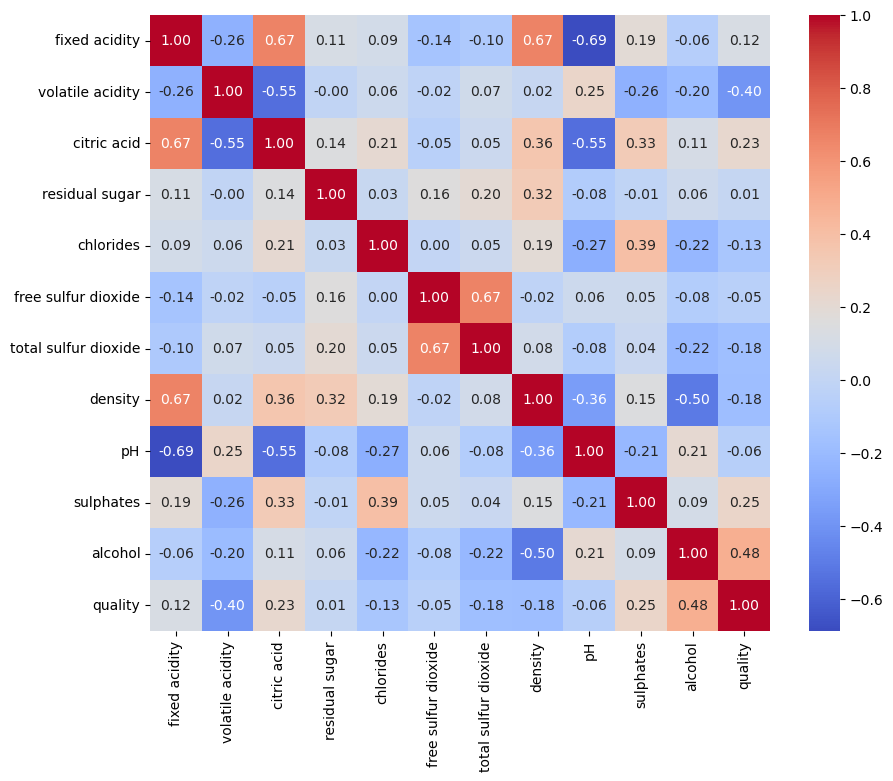

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

<p style="color: green; text-align: justify;">
Korelasyon analizi, quality ile bazı değişkenler arasında doğrusal ilişkiler olduğunu göstermiştir. Alcohol pozitif; volatile acidity ve total sulfur dioxide ise negatif yönde ilişki göstermektedir.
</p>


In [11]:
(data["quality"].value_counts()).sort_index(ascending=True) #hedef değişken dağılımı

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

<p style="color: green; text-align: justify;">
Quality değişkeninin dağılımı dengesiz bir yapı göstermektedir. Bu çalışmada, analiz ve yorumlamayı sadeleştirmek amacıyla kalite puanı 6.5 ve üzeri olan şaraplar “iyi”, diğerleri ise “iyi değil” olarak ikili sınıflandırma problemine dönüştürülmüştür.
</p>


In [12]:
data["quality_class"] = (data["quality"] >= 6.5).astype(int) 

In [13]:
data["quality_class"].value_counts()

quality_class
0    1175
1     184
Name: count, dtype: int64

In [14]:
X = data.drop(columns=["quality", "quality_class"])
y = data["quality_class"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### **RANDOM FOREST**

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, classification_report, confusion_matrix


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [17]:
acc_rf = accuracy_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_proba)

print("Accuracy:", acc_rf)
print("Recall:", rec_rf)
print("AUC:", auc_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8933823529411765
Recall: 0.35135135135135137
AUC: 0.8622771707878092

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       235
           1       0.72      0.35      0.47        37

    accuracy                           0.89       272
   macro avg       0.81      0.67      0.71       272
weighted avg       0.88      0.89      0.88       272

Confusion Matrix:
 [[230   5]
 [ 24  13]]


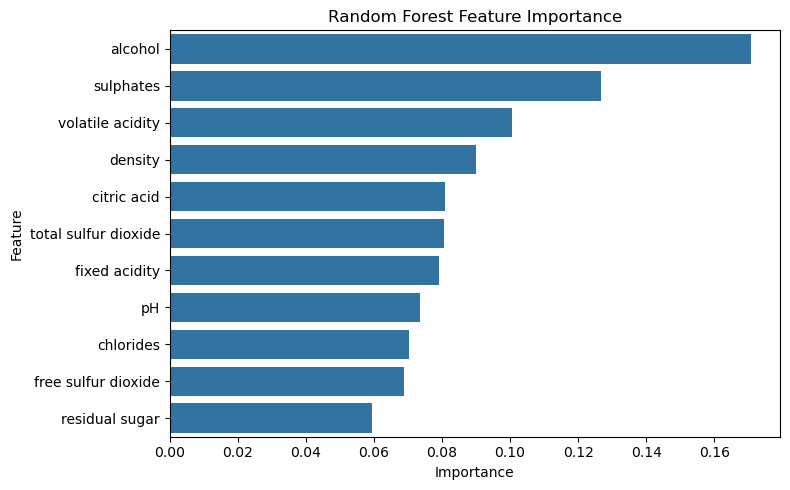

In [18]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<p style="color: green; text-align: justify;">
Random Forest modeli yüksek AUC değeri ile şarap kalitesini ayırt edebilmiştir. Recall değerinin görece düşük olması sınıf dengesizliği ile ilişkilidir.
</p>


#### **LOGİSTİC REGRESSİON**

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "auc": "roc_auc"
}

cv_results = cross_validate(
    pipe_lr,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("CV Accuracy (mean):", np.mean(cv_results["test_accuracy"]))
print("CV Recall (mean):", np.mean(cv_results["test_recall"]))
print("CV AUC (mean):", np.mean(cv_results["test_auc"]))

CV Accuracy (mean): 0.8703124339407262
CV Recall (mean): 0.2852873563218391
CV AUC (mean): 0.8533761310833945


In [20]:
pipe_lr_final = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])


pipe_lr_final.fit(X_train, y_train)


y_pred_lr = pipe_lr_final.predict(X_test)
y_proba_lr = pipe_lr_final.predict_proba(X_test)[:, 1]


acc_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Test Accuracy:", acc_lr)
print("Test Recall:", rec_lr)
print("Test AUC:", auc_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Test Accuracy: 0.875
Test Recall: 0.24324324324324326
Test AUC: 0.8860264519838988

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       235
           1       0.60      0.24      0.35        37

    accuracy                           0.88       272
   macro avg       0.75      0.61      0.64       272
weighted avg       0.85      0.88      0.85       272

Confusion Matrix:
 [[229   6]
 [ 28   9]]


In [21]:
coef = pipe_lr_final.named_steps["lr"].coef_[0]
features = X_train.columns

coef_df = pd.Series(coef, index=features).sort_values(ascending=False)
coef_df

alcohol                 0.900057
sulphates               0.541116
fixed acidity           0.380001
residual sugar          0.195311
citric acid            -0.047463
free sulfur dioxide    -0.051454
pH                     -0.133652
density                -0.300335
total sulfur dioxide   -0.337110
chlorides              -0.378406
volatile acidity       -0.593284
dtype: float64

<p style="color: green; text-align: justify;">
Logistic Regression modeli test setinde yüksek AUC değeri elde etmiştir. Katsayılar, alcohol ve sulphates değişkenlerinin pozitif; volatile acidity değişkeninin ise negatif yönde etkili olduğunu göstermektedir.
</p>


#### **GRADİENT BOOSTİNG**

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb = GradientBoostingClassifier(random_state=42)

scoring = {"accuracy": "accuracy", "recall": "recall", "auc": "roc_auc"}

cv_results_gb = cross_validate(
    gb,
    X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("GB CV Accuracy (mean):", np.mean(cv_results_gb["test_accuracy"]))
print("GB CV Recall (mean):", np.mean(cv_results_gb["test_recall"]))
print("GB CV AUC (mean):", np.mean(cv_results_gb["test_auc"]))

GB CV Accuracy (mean): 0.8711833594047267
GB CV Recall (mean): 0.3524137931034483
GB CV AUC (mean): 0.8551442895573491


In [23]:

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

print("GB Test Accuracy:", acc_gb)
print("GB Test Recall:", rec_gb)
print("GB Test AUC:", auc_gb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))

GB Test Accuracy: 0.8713235294117647
GB Test Recall: 0.35135135135135137
GB Test AUC: 0.8912018401380104

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93       235
           1       0.54      0.35      0.43        37

    accuracy                           0.87       272
   macro avg       0.72      0.65      0.68       272
weighted avg       0.85      0.87      0.86       272

Confusion Matrix:
 [[224  11]
 [ 24  13]]


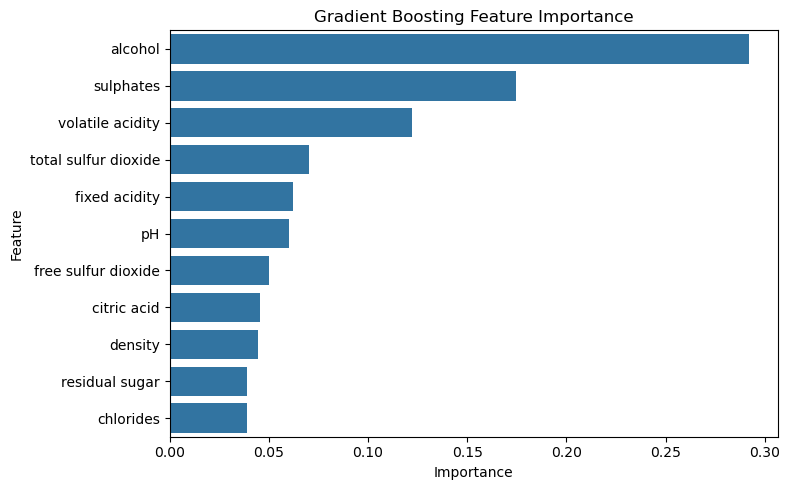

In [24]:
gb_imp = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=gb_imp, y=gb_imp.index)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

<p style="color: green; text-align: justify;">
Gradient Boosting modeli yüksek AUC değeri ile istikrarlı bir performans sergilemiştir. Recall değerinin Random Forest ile benzer seviyede olduğu görülmüştür.
</p>


In [25]:
results = pd.DataFrame([
    {"Model": "Random Forest", 
     "Accuracy": acc_rf, 
     "Recall": rec_rf, 
     "AUC": auc_rf},

    {"Model": "Logistic Regression", 
     "Accuracy": acc_lr, 
     "Recall": rec_lr, 
     "AUC": auc_lr},

    {"Model": "Gradient Boosting", 
     "Accuracy": acc_gb, 
     "Recall": rec_gb, 
     "AUC": auc_gb},
])

results

,Model,Accuracy,Recall,AUC
0,Random Forest,0.893382,0.351351,0.862277
1,Logistic Regression,0.875000,0.243243,0.886026
2,Gradient Boosting,0.871324,0.351351,0.891202


<h2>SONUÇ</h2>

<p style="text-indent: 40px; text-align: justify;">
Random Forest, Logistic Regression ve Gradient Boosting modelleri benzer ve yüksek AUC değerleri elde ederek şarap kalitesinin anlamlı şekilde ayırt edilebildiğini göstermiştir. Ağaç tabanlı modellerin recall değerlerinin daha yüksek olması, iyi şarapları yakalama açısından daha başarılı olduklarını ortaya koymaktadır. Recall değerlerinin görece düşük kalması ise veri setindeki sınıf dengesizliği ve varsayılan karar eşiği ile ilişkilidir.
</p>

<p style="text-indent: 40px; text-align: justify;">
Model sonuçları birlikte değerlendirildiğinde, bir şarabın “iyi” olarak sınıflandırılmasında en belirleyici özelliğin yüksek alcohol oranı olduğu görülmüştür. Ayrıca sulphates değişkeni kaliteyi pozitif yönde etkilerken; yüksek volatile acidity, chlorides ve total sulfur dioxide seviyelerinin kalite üzerinde olumsuz etkisi bulunmaktadır. Farklı modellerde büyük ölçüde benzer değişkenlerin öne çıkması, elde edilen bulguların tutarlı olduğunu göstermektedir.
</p>
